In [ ]:
# Core libs for file handling, arrays, dataframes, and plotting
import os  # filesystem paths and directory utilities
import numpy as np  # vectorized numerical ops
import pandas as pd  # tabular data handling
import seaborn as sns  # statistical plotting
sns.set_style('darkgrid')  # consistent dark grid background for plots
import matplotlib.pyplot as plt  # plotting primitives
from sklearn.model_selection import train_test_split  # dataset splitting helper
from sklearn.metrics import confusion_matrix, classification_report  # evaluation metrics

from PIL import Image  # image I/O and basic manipulation

# Deep learning stack (TensorFlow/Keras) and computer vision helpers
import tensorflow as tf  # core TensorFlow engine
from tensorflow import keras  # Keras high-level API
from tensorflow.keras.models import Sequential  # linear stack of layers
from tensorflow.keras.optimizers import Adam, Adamax  # optimizers
from tensorflow.keras.metrics import categorical_crossentropy  # loss metric alias
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # augmentation pipeline
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization  # layer building blocks
from tensorflow.keras import regularizers  # weight regularization
import cv2  # OpenCV for image processing
import warnings  # control warnings
from tqdm import tqdm  # progress bars

# Silence noisy warnings to keep notebook output clean
warnings.filterwarnings("ignore")

print('modules loaded')  # quick sanity check that imports succeeded

modules loaded


In [ ]:
# Define base dataset folder and split-specific paths
dataset_path = "dataset"  # root folder holding train/val/test

train_path = os.path.join(dataset_path, "train")  # training images
val_path = os.path.join(dataset_path, "val")  # validation images
test_path = os.path.join(dataset_path, "test")  # test images

In [ ]:
# Inspect available class folders under the training split
classes = os.listdir(train_path)  # list class folder names inside train
print("Classes:", classes)  # show class labels detected

Classes: ['0_normal', '1_ulcerative_colitis', '2_polyps', '3_esophagitis']


In [ ]:
# Helper to count images per class inside a split folder
def count_images(folder):
    counts = {}  # accumulator for {class: count}
    for cls in os.listdir(folder):  # iterate class folders
        cls_path = os.path.join(folder, cls)  # full path to class dir
        counts[cls] = len(os.listdir(cls_path))  # number of files in class dir
    return counts

# Tally image counts across splits to check balance
train_counts = count_images(train_path)
val_counts = count_images(val_path)
test_counts = count_images(test_path)

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Train: {'0_normal': 800, '1_ulcerative_colitis': 800, '2_polyps': 800, '3_esophagitis': 800}
Validation: {'0_normal': 500, '1_ulcerative_colitis': 500, '2_polyps': 500, '3_esophagitis': 500}
Test: {'0_normal': 200, '1_ulcerative_colitis': 200, '2_polyps': 200, '3_esophagitis': 200}


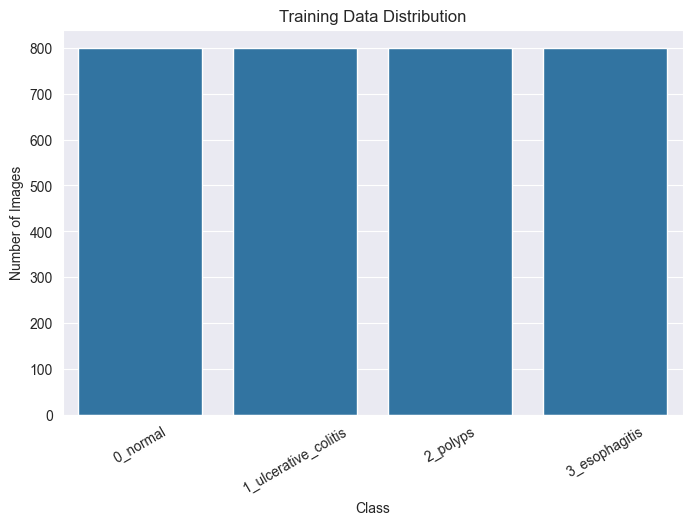

In [ ]:
# Visualize class distribution in the training split
plt.figure(figsize=(8,5))  # set canvas size
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))  # bars for each class count
plt.title("Training Data Distribution")  # chart title
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)  # tilt labels for readability
plt.show()

In [ ]:
# Build a dataframe listing every image with its split and label
records = []  # accumulator rows

for split in ['train','val','test']:
    split_path = os.path.join(dataset_path, split)  # current split folder

    for label in os.listdir(split_path):
        class_path = os.path.join(split_path, label)  # class folder path

        for img in os.listdir(class_path):
            records.append({
                "split": split,  # which split this file belongs to
                "label": label,  # class name
                "filepath": os.path.join(class_path, img)  # full file path
            })

eda_df = pd.DataFrame(records)  # assemble rows into dataframe

print("Total images:", len(eda_df))
eda_df.head()  # preview first rows

Total images: 6000


,split,label,filepath
0,train,0_normal,dataset\train\0_normal\train_normal_ (1).jpg
1,train,0_normal,dataset\train\0_normal\train_normal_ (10).jpg
2,train,0_normal,dataset\train\0_normal\train_normal_ (100).jpg
3,train,0_normal,dataset\train\0_normal\train_normal_ (101).jpg
4,train,0_normal,dataset\train\0_normal\train_normal_ (102).jpg


In [ ]:
# Sample image dimensions to understand typical sizes
sizes = []  # holds (width, height) tuples

sample_paths = eda_df['filepath'].sample(200)  # random subset of images

for path in sample_paths:
    img = Image.open(path)  # open image
    sizes.append(img.size)  # record (width, height)

size_df = pd.DataFrame(sizes, columns=['width','height'])  # to analyze size distribution

print(size_df.describe())  # summary stats for width/height

            width       height
count   200.00000   200.000000
mean    825.42500   656.365000
std     324.53039   196.118751
min     562.00000   502.000000
25%     633.00000   532.000000
50%     720.00000   576.000000
75%     720.00000   576.000000
max    1920.00000  1072.000000


In [ ]:
# Inspect pixel value range on a sample image
sample_img = np.array(Image.open(eda_df['filepath'].iloc[0]))  # load first image into array

print("Min pixel value:", sample_img.min())  # darkest pixel
print("Max pixel value:", sample_img.max())  # brightest pixel

Min pixel value: 0
Max pixel value: 255


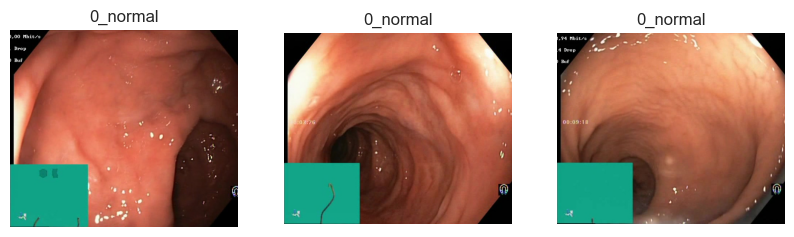

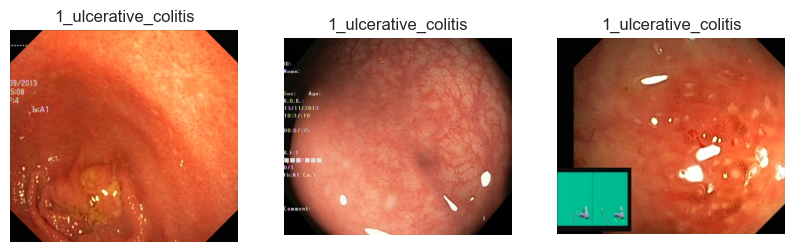

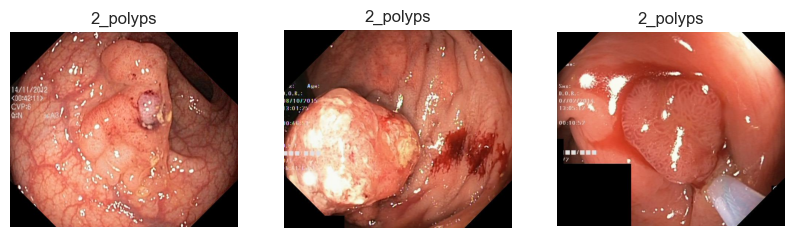

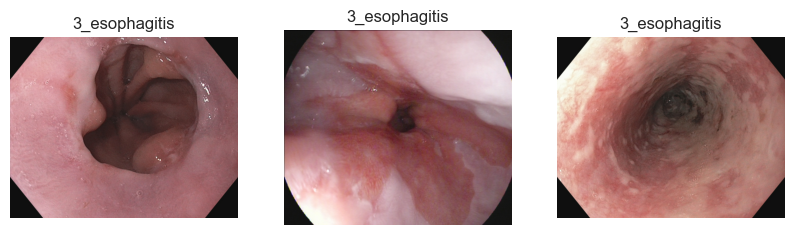

In [ ]:
# Show a few example images per class to spot visual patterns
samples_per_class = 3  # images per label to display

for label in classes:
    class_path = os.path.join(train_path, label)  # folder for this label

    images = os.listdir(class_path)[:samples_per_class]  # pick first few files

    plt.figure(figsize=(10,3))  # one row of subplots

    for i, img_name in enumerate(images):
        img = cv2.imread(os.path.join(class_path, img_name))  # load with OpenCV (BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for plotting

        plt.subplot(1,3,i+1)  # select subplot slot
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")  # hide axes for clarity

    plt.show()

In [ ]:
# Check for unreadable/corrupted images
broken = []  # collect paths that fail to open

for path in eda_df['filepath']:
    try:
        Image.open(path)  # attempt to open
    except:
        broken.append(path)  # record failures

print("Broken images:", len(broken))

Broken images: 0


In [ ]:
# Build a sampled stats dataframe capturing geometry, color, and texture features per image
tqdm.pandas()  # enable pandas integration for progress bars

# Sample a manageable subset to compute stats
stat_sample = eda_df.sample(min(len(eda_df), 600), random_state=42).reset_index(drop=True)  # limit to 600 for speed
stat_records = []  # feature rows

for _, row in tqdm(stat_sample.iterrows(), total=len(stat_sample)):
    img = Image.open(row['filepath']).convert('RGB')  # read image as RGB
    arr = np.array(img)  # to numpy
    h, w, _ = arr.shape  # spatial dims
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)  # grayscale version
    hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)  # HSV for brightness/saturation
    sobel = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)  # edge response

    # Aggregate per-image stats for later plots
    stat_records.append({
        'split': row['split'],  # which split
        'label': row['label'],  # class
        'width': w,
        'height': h,
        'area': w * h,  # pixel count
        'aspect': w / h,  # width/height ratio
        'orientation': 'landscape' if w > h else ('portrait' if h > w else 'square'),
        'mean_r': arr[:, :, 0].mean(),  # average red
        'mean_g': arr[:, :, 1].mean(),  # average green
        'mean_b': arr[:, :, 2].mean(),  # average blue
        'brightness_v': hsv[:, :, 2].mean(),  # value channel mean
        'saturation_s': hsv[:, :, 1].mean(),  # saturation channel mean
        'contrast_gray': gray.std(),  # grayscale std as contrast proxy
        'edge_strength': np.mean(np.abs(sobel)),  # mean absolute edge magnitude
        'file_kb': os.path.getsize(row['filepath']) / 1024  # file size in KB
    })

stat_df = pd.DataFrame(stat_records)  # assemble feature table
stat_df['resolution'] = stat_df['width'].astype(str) + 'x' + stat_df['height'].astype(str)  # human-readable size

print(stat_df.head())
print('\nSample size used:', len(stat_df))

100%|██████████| 600/600 [00:20<00:00, 29.14it/s]

   split                 label  width  height    area    aspect orientation  \
0  train              2_polyps    584     530  309520  1.101887   landscape   
1    val  1_ulcerative_colitis    720     576  414720  1.250000   landscape   
2  train              0_normal    633     532  336756  1.189850   landscape   
3  train              2_polyps    620     530  328600  1.169811   landscape   
4   test              0_normal    720     576  414720  1.250000   landscape   

       mean_r     mean_g     mean_b  brightness_v  saturation_s  \
0  147.088485  86.372044  59.832134    147.143364    130.704701   
1  109.289200  62.093540  50.083818    109.416840    122.107494   
2  133.489354  93.270959  71.508828    148.764506    152.274142   
3  125.611741  68.798478  50.583357    125.676935    137.277946   
4   78.129509  51.977059  40.748949     90.432815    140.710851   

   contrast_gray  edge_strength     file_kb resolution  
0      59.396015       4.793513   34.142578    584x530  
1      6

**Why Visual 1 & 2 (count plots)**: Bar counts reveal whether splits or labels are imbalanced. They use seaborn `countplot` to tally rows from `eda_df`, showing split and class frequencies. Without these, we could miss data imbalance that skews training/validation and metrics.

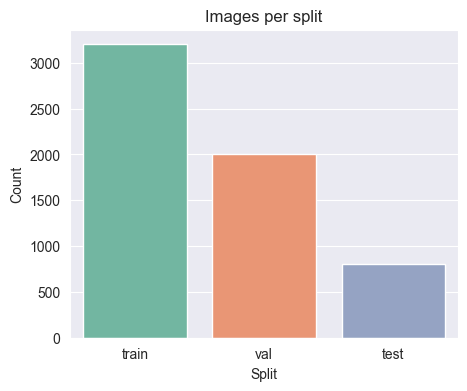

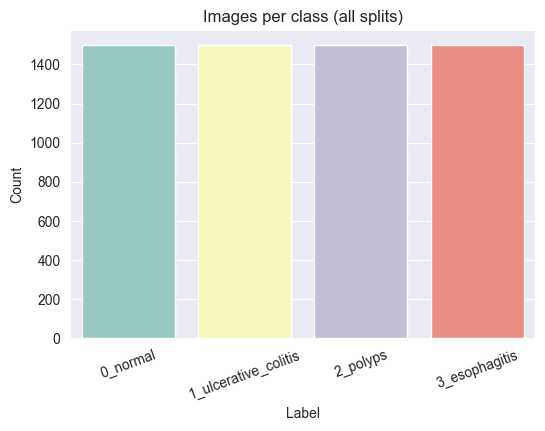

In [ ]:
# Visual 1: overall split distribution
plt.figure(figsize=(5,4))  # compact bar chart
sns.countplot(data=eda_df, x='split', order=['train','val','test'], palette='Set2')  # bars per split
plt.title('Images per split')
plt.xlabel('Split')
plt.ylabel('Count')
plt.show()

# Visual 2: overall class distribution across all splits
plt.figure(figsize=(6,4))
sns.countplot(data=eda_df, x='label', order=sorted(eda_df['label'].unique()), palette='Set3')  # bars per label
plt.title('Images per class (all splits)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=20)  # tilt labels for readability
plt.show()

**Why Visual 3 & 4 (stacked/grouped bars)**: These compare class counts across train/val/test in one view using the precomputed `counts` table. Stacked shows total volume; grouped highlights per-split differences. Skipping them hides split-specific imbalance that can cause biased evaluation or sampling issues.

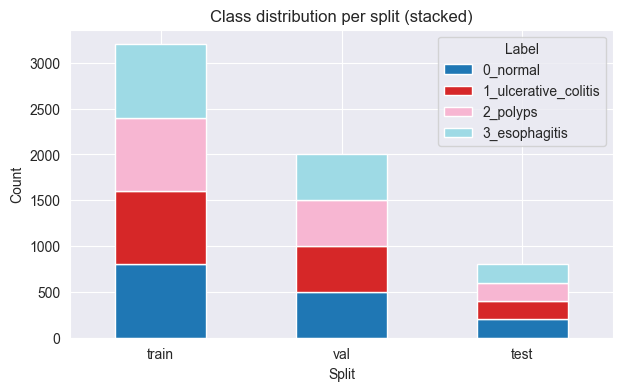

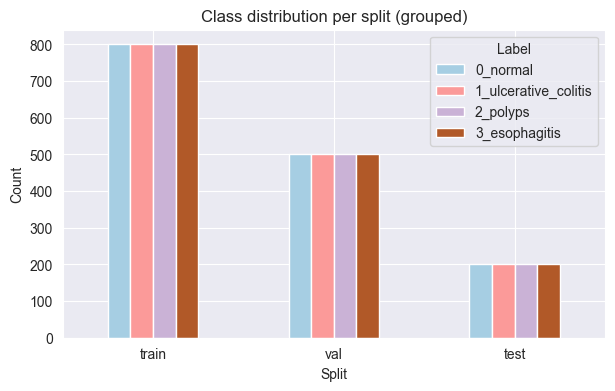

In [ ]:
# Compare class counts per split using stacked and grouped bars
counts = eda_df.groupby(['split','label']).size().unstack(fill_value=0)[sorted(eda_df['label'].unique())]  # pivot counts
counts.loc[['train','val','test']].plot(kind='bar', stacked=True, figsize=(7,4), colormap='tab20')  # stacked view
plt.title('Class distribution per split (stacked)')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

counts.loc[['train','val','test']].plot(kind='bar', stacked=False, figsize=(7,4), colormap='Paired')  # grouped bars
plt.title('Class distribution per split (grouped)')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

**Why Visual 5 (heatmap)**: Heatmap of the `counts` matrix quickly spotlights over/under-represented class-split combos with color intensity. Without it, we rely on numbers alone and may overlook sparse cells that can cause poor generalization for specific classes in a split.

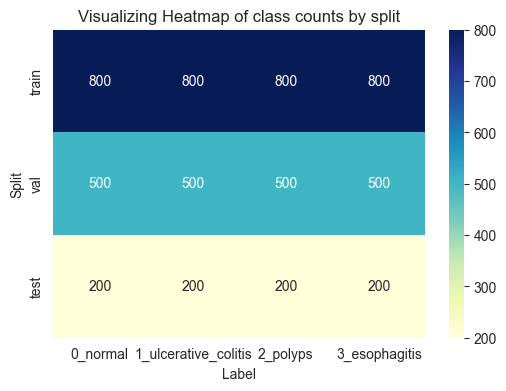

In [ ]:
# Heatmap to highlight count imbalances across split/label
plt.figure(figsize=(6,4))
sns.heatmap(counts.loc[['train','val','test']], annot=True, fmt='d', cmap='YlGnBu')  # color-coded counts
plt.title('Visualizing Heatmap of class counts by split')
plt.xlabel('Label')
plt.ylabel('Split')
plt.show()

**Why Visual 6 & 7 (pie charts)**: Pies summarize proportion of labels overall and splits overall, emphasizing share instead of counts. They make imbalance intuitive at a glance. Omitting them removes an easy percentage view; you’d rely on bar heights only, which can hide proportion differences when totals vary.

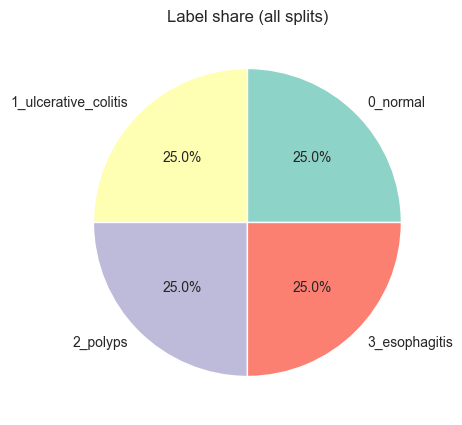

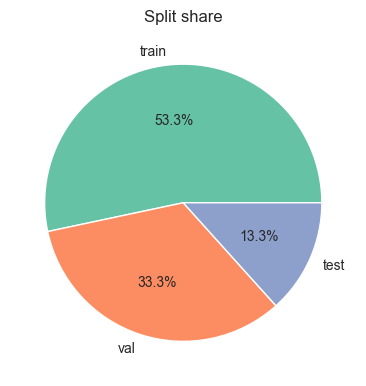

In [ ]:
# Pie charts summarizing label and split proportions
plt.figure(figsize=(5,5))
eda_df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set3'))  # label share
plt.ylabel('')
plt.title('Label share (all splits)')
plt.show()

plt.figure(figsize=(4.5,4.5))
eda_df['split'].value_counts().reindex(['train','val','test']).plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('Set2'))  # split share
plt.ylabel('')
plt.title('Split share')
plt.show()

**Why Visual 8 & 9 (width/height histograms)**: Histograms of dimensions show common image sizes and spread, guiding resize strategy. Without them we might choose an input size that crops or stretches many images, hurting model quality.

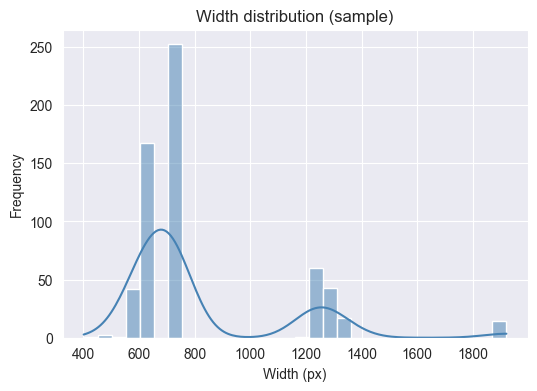

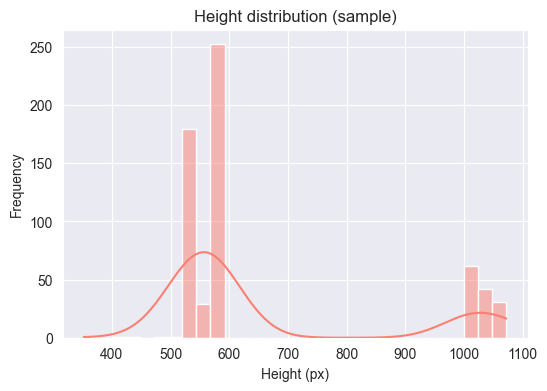

In [ ]:
# Width and height distributions from sampled stats
plt.figure(figsize=(6,4))
sns.histplot(stat_df['width'], bins=30, color='steelblue', kde=True)  # histogram of widths
plt.title('Width distribution (sample)')
plt.xlabel('Width (px)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(stat_df['height'], bins=30, color='salmon', kde=True)  # histogram of heights
plt.title('Height distribution (sample)')
plt.xlabel('Height (px)')
plt.ylabel('Frequency')
plt.show()

**Why Visual 10 & 11 (hexbin + aspect histogram)**: Hexbin shows joint density of width vs height to spot typical resolutions and outliers; the aspect histogram shows shape tendencies. Skipping them hides whether sizes cluster along certain diagonals or if extreme aspect ratios need special handling.

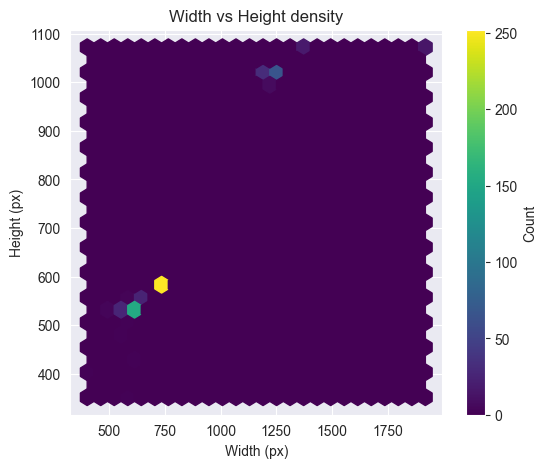

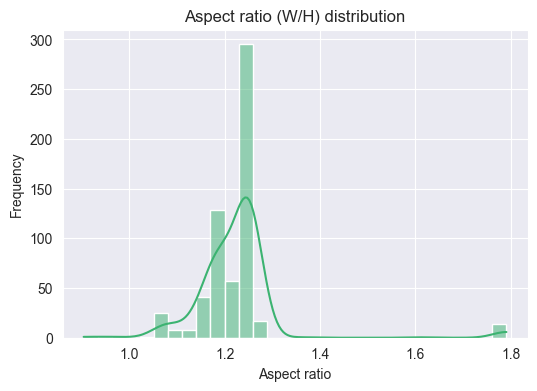

In [ ]:
# Joint view of width vs height plus aspect ratio distribution
plt.figure(figsize=(6,5))
plt.hexbin(stat_df['width'], stat_df['height'], gridsize=25, cmap='viridis')  # 2D density of sizes
plt.title('Width vs Height density')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
cb = plt.colorbar()
cb.set_label('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(stat_df['aspect'], bins=30, color='mediumseagreen', kde=True)  # aspect ratio distribution
plt.title('Aspect ratio (W/H) distribution')
plt.xlabel('Aspect ratio')
plt.ylabel('Frequency')
plt.show()

**Why Visual 12–14 (boxplots width/height/aspect by label)**: Boxplots compare geometry across classes to detect if one class has systematically different image sizes or shapes. Without them, class-specific preprocessing needs could be missed, leading to distortions for certain labels.

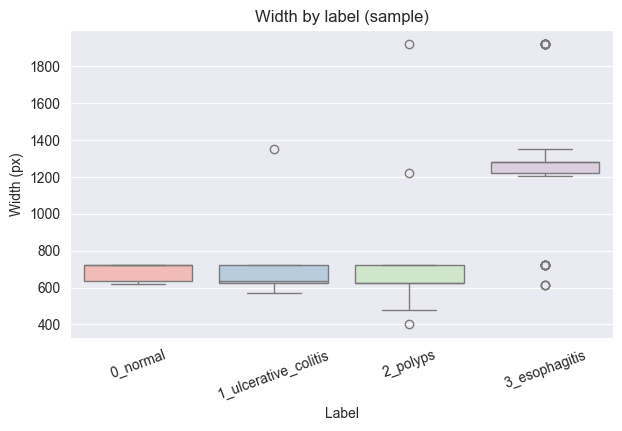

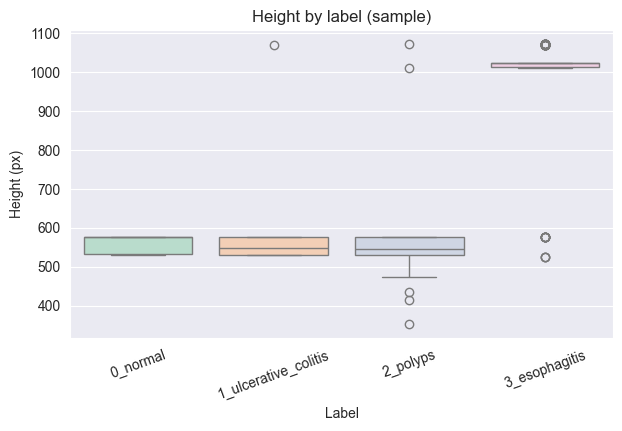

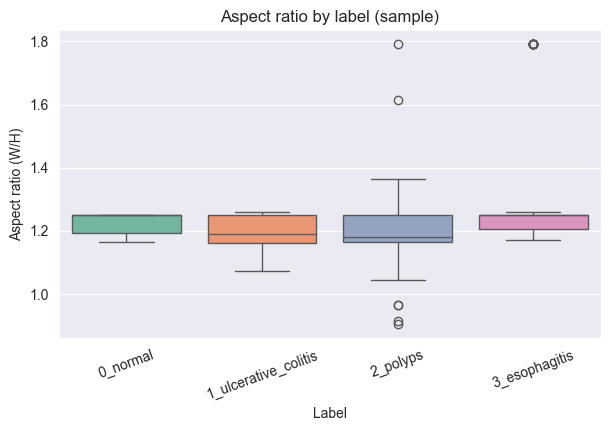

In [ ]:
# Boxplots to compare geometry across labels
plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='width', order=sorted(stat_df['label'].unique()), palette='Pastel1')  # width per class
plt.title('Width by label (sample)')
plt.xlabel('Label')
plt.ylabel('Width (px)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='height', order=sorted(stat_df['label'].unique()), palette='Pastel2')  # height per class
plt.title('Height by label (sample)')
plt.xlabel('Label')
plt.ylabel('Height (px)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='aspect', order=sorted(stat_df['label'].unique()), palette='Set2')  # aspect ratio per class
plt.title('Aspect ratio by label (sample)')
plt.xlabel('Label')
plt.ylabel('Aspect ratio (W/H)')
plt.xticks(rotation=20)
plt.show()

**Why Visual 15 & 16 (orientation counts, area histogram)**: Orientation counts reveal dominant landscape/portrait mix, informing augmentation strategy; area histogram shows pixel count scale. Skipping them risks choosing crops/resize policies that penalize minority orientations or overwhelm memory with very large images.

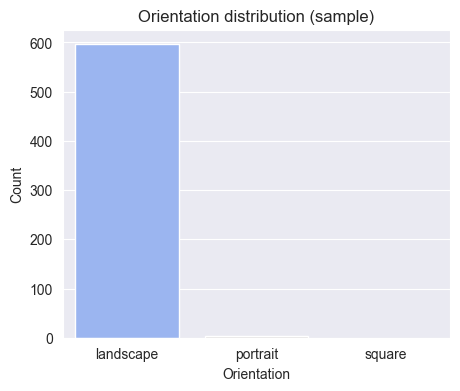

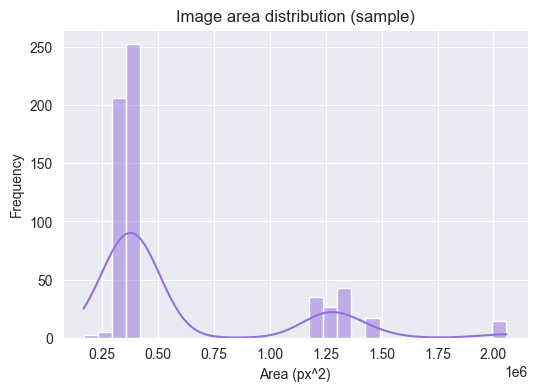

In [ ]:
# Orientation mix and overall pixel area distribution
plt.figure(figsize=(5,4))
sns.countplot(data=stat_df, x='orientation', order=['landscape','portrait','square'], palette='coolwarm')  # orientation counts
plt.title('Orientation distribution (sample)')
plt.xlabel('Orientation')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(stat_df['area'], bins=30, color='mediumpurple', kde=True)  # pixel area histogram
plt.title('Image area distribution (sample)')
plt.xlabel('Area (px^2)')
plt.ylabel('Frequency')
plt.show()

**Why Visual 17 (grayscale histogram)**: Sampling grayscale pixels shows contrast and brightness spread, indicating if normalization or CLAHE might help. Without it, we might miss low-contrast images that hinder edge detectors and CNN learning.

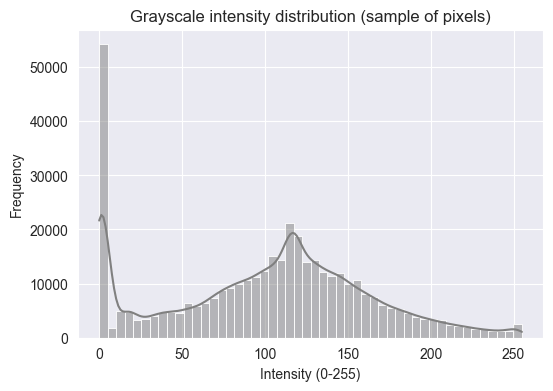

In [ ]:
# Sample pixel intensities to see grayscale distribution
plt.figure(figsize=(6,4))
gray_values = []  # sampled grayscale pixels
for path in stat_sample['filepath'][:200]:  # limit to avoid huge arrays
    g = np.array(Image.open(path).convert('L')).flatten()  # grayscale pixels
    gray_values.extend(g[np.random.choice(len(g), size=min(2000, len(g)), replace=False)])  # random subset per image
sns.histplot(gray_values, bins=50, color='gray', kde=True)
plt.title('Grayscale intensity distribution (sample of pixels)')
plt.xlabel('Intensity (0-255)')
plt.ylabel('Frequency')
plt.show()

**Why Visual 18 (mean RGB histograms)**: Shows distribution of per-image channel means, revealing color cast or illumination bias. Skipping it hides whether a color normalization step (e.g., per-channel standardization) is needed to stabilize training.

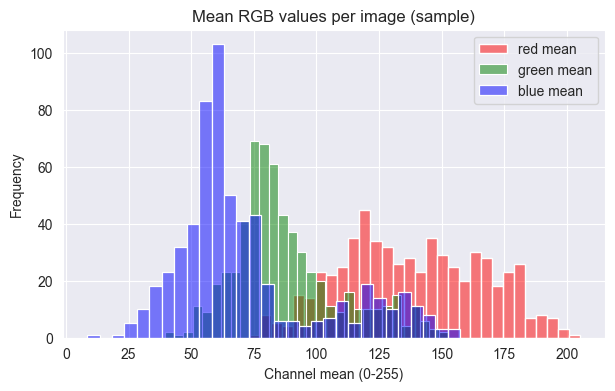

In [ ]:
# Distribution of per-image mean RGB channels
plt.figure(figsize=(7,4))
channel_colors = ['red','green','blue']
for ch, color in enumerate(channel_colors):
    sns.histplot(stat_df[[f'mean_{c}' for c in ['r','g','b']][ch]], bins=30, color=color, label=f'{color} mean', alpha=0.5)  # channel mean histogram
plt.title('Mean RGB values per image (sample)')
plt.xlabel('Channel mean (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Why Visual 19 (mean RGB per class)**: Class-level barplot checks if certain labels have systematic color differences, which might be discriminative or require balancing. Without it, we could miss color leakage cues or fail to apply augmentations that reduce over-reliance on color.

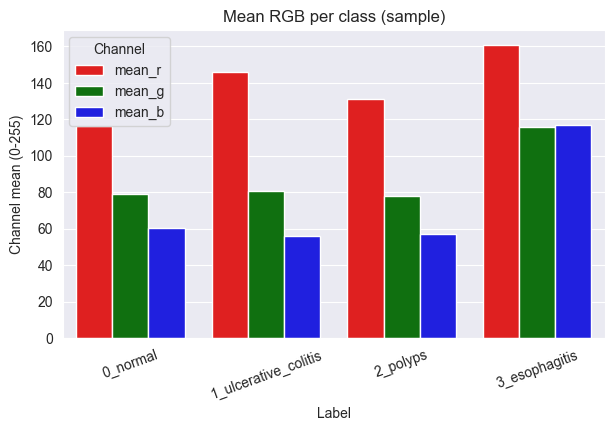

In [ ]:
# Compare average RGB levels across classes
rgb_means = stat_df.groupby('label')[['mean_r','mean_g','mean_b']].mean().reset_index()  # per-class averages
rgb_melt = rgb_means.melt(id_vars='label', var_name='channel', value_name='mean_val')  # long format for seaborn
plt.figure(figsize=(7,4))
sns.barplot(data=rgb_melt, x='label', y='mean_val', hue='channel', palette={'mean_r':'red','mean_g':'green','mean_b':'blue'})
plt.title('Mean RGB per class (sample)')
plt.xlabel('Label')
plt.ylabel('Channel mean (0-255)')
plt.xticks(rotation=20)
plt.legend(title='Channel')
plt.show()

**Why Visual 20–23 (brightness/saturation/contrast/edges by label)**: Boxplots of V, S, gray std, and Sobel edge strength highlight per-class texture/lightness differences. Skipping them hides whether some classes are darker, less saturated, or smoother—factors that can cause biased feature learning or suggest preprocessing (e.g., histogram equalization, sharpening).

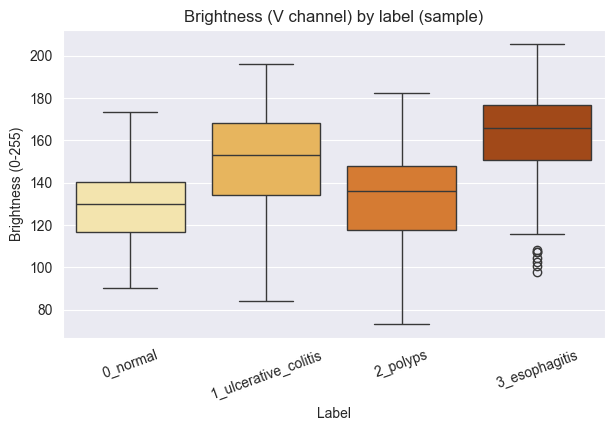

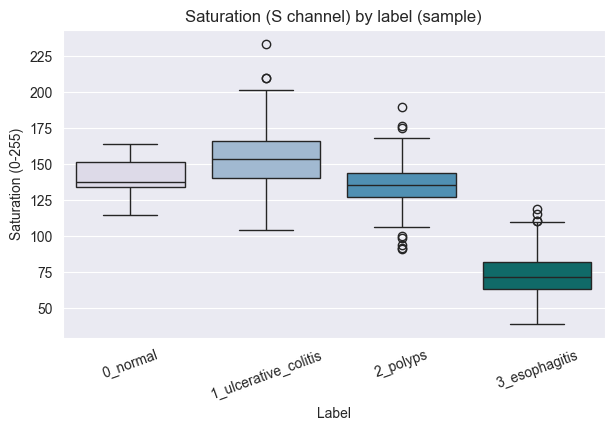

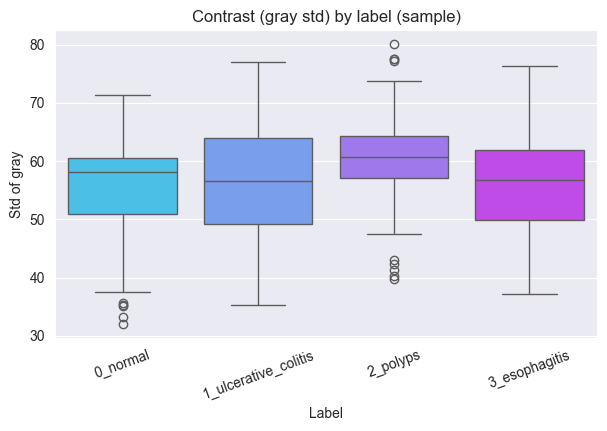

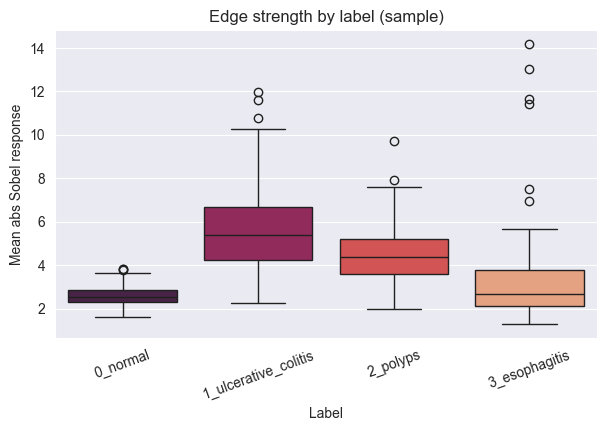

In [ ]:
# Compare brightness, saturation, contrast, and edge strength per class
plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='brightness_v', order=sorted(stat_df['label'].unique()), palette='YlOrBr')  # V channel per class
plt.title('Brightness (V channel) by label (sample)')
plt.xlabel('Label')
plt.ylabel('Brightness (0-255)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='saturation_s', order=sorted(stat_df['label'].unique()), palette='PuBuGn')  # saturation per class
plt.title('Saturation (S channel) by label (sample)')
plt.xlabel('Label')
plt.ylabel('Saturation (0-255)')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='contrast_gray', order=sorted(stat_df['label'].unique()), palette='cool')  # grayscale contrast per class
plt.title('Contrast (gray std) by label (sample)')
plt.xlabel('Label')
plt.ylabel('Std of gray')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=stat_df, x='label', y='edge_strength', order=sorted(stat_df['label'].unique()), palette='rocket')  # edge strength per class
plt.title('Edge strength by label (sample)')
plt.xlabel('Label')
plt.ylabel('Mean abs Sobel response')
plt.xticks(rotation=20)
plt.show()

**Why Visual 24 & 25 (correlation heatmap, top resolutions)**: Correlation map shows relationships among numeric features (size, color, texture), guiding feature selection or decorrelation. Top-resolution bar plot surfaces the most common shapes to pick efficient resizing targets. Without these, we might choose redundant features or an inefficient canonical resolution, wasting compute or losing detail.

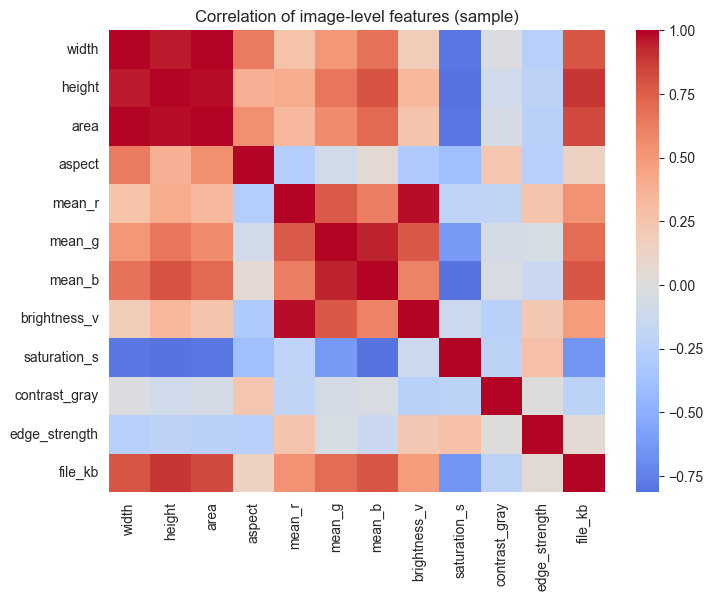

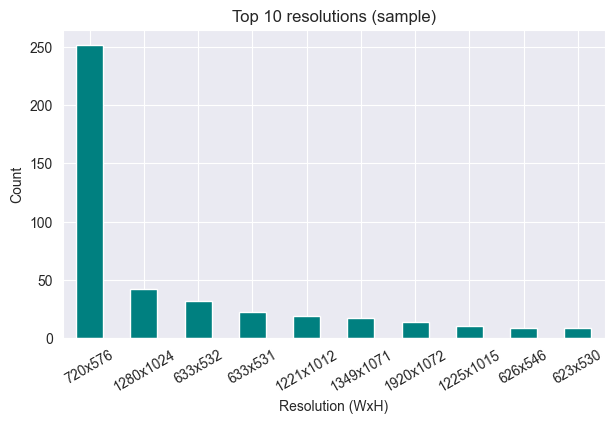

In [ ]:
# Correlation across numeric features and most common resolutions
plt.figure(figsize=(8,6))
num_cols = ['width','height','area','aspect','mean_r','mean_g','mean_b','brightness_v','saturation_s','contrast_gray','edge_strength','file_kb']  # numeric feature list
corr = stat_df[num_cols].corr()  # correlation matrix
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)  # visualize correlations
plt.title('Correlation of image-level features (sample)')
plt.show()

plt.figure(figsize=(7,4))
stat_df['resolution'].value_counts().head(10).plot(kind='bar', color='teal')  # top resolutions
plt.title('Top 10 resolutions (sample)')
plt.xlabel('Resolution (WxH)')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()